# Gulf States Gas Flares — VIIRS Nightfire Analysis

Monthly bar chart time series + high-temp flare map + CSV export.

In [1]:
from pathlib import Path
from flare_analysis import (
    download_firms, load_and_process,
    build_monthly_timeseries, apply_scale_factors,
    plot_timeseries_bars, plot_hightemp_map, export_csv,
)

## 1. Configuration

In [2]:
PARQUET_PATH = Path("data/raw_gulf_oct22_oct23.parquet")
OUTPUT_DIR = Path("data")

COUNTRY_BBOX = {
    "Kuwait":        (46.5, 28.5, 48.5, 30.1),
    "Iraq":          (38.8, 29.0, 48.6, 37.4),
    "Iran":          (44.0, 25.0, 63.3, 39.8),
    "Saudi Arabia":  (34.5, 16.3, 55.7, 32.2),
    "UAE":           (51.5, 22.6, 56.4, 26.1),
    "Qatar":         (50.7, 24.4, 51.7, 26.2),
    "Bahrain":       (50.3, 25.7, 50.8, 26.3),
    "Oman":          (51.8, 16.6, 59.8, 26.4),
    "Yemen":         (42.5, 12.1, 54.5, 19.0),
}

# Map date range
MAP_DATE_START = "2023-06-01"
MAP_DATE_END   = "2023-06-07"

## 1b. Download data (run once, then skip)

Requires `config.py` with your `FIRMS_MAP_KEY`. Skip this cell if parquet already exists.

In [3]:
if not PARQUET_PATH.exists():
    from config import FIRMS_MAP_KEY
    download_firms(
        api_key=FIRMS_MAP_KEY,
        bbox="44,16,60,36",
        start_date="2022-10-01",
        end_date="2023-06-07",
        output_path=PARQUET_PATH,
    )
else:
    print(f"Data exists: {PARQUET_PATH}")

Data exists: data\raw_gulf_oct22_oct23.parquet


## 2. Load & process data (Planck fitting)

In [4]:
df = load_and_process(PARQUET_PATH, COUNTRY_BBOX)

Loaded: 502,025 rows
Filtered: 502,025 -> 372,779
Running Planck fitting...
Result: 328,094 detections, 7 countries


## 3. Monthly time series

In [5]:
timeseries = build_monthly_timeseries(df)
timeseries

country,Iran,Iraq,Saudi Arabia,Oman,Kuwait,Qatar,Yemen
month,,,,,,,
2022-10-01,26331,16355,3903,2566,955,254,0
2022-11-01,17114,11081,3689,2394,777,228,3
2022-12-01,16864,11741,3858,2425,900,218,0
2023-01-01,11740,10829,3057,1974,789,204,5
2023-02-01,14413,10216,3603,2095,695,226,1
2023-03-01,19781,11623,3809,2323,697,259,3
2023-04-01,24604,12532,3181,2012,708,248,1
2023-05-01,31048,15135,3772,2240,800,195,5
2023-06-01,6444,3476,879,544,226,43,3


## 4. Scale factors (parameters)

Multiply monthly detection counts per country.  
`1.0` = no change, `2.0` = double, `0.5` = halve.  
Countries not listed keep original values.

In [6]:
# ── EDIT THESE ──
SCALE_FACTORS = {
    "Iran":          1.0,
    "Iraq":          1.0,
    "Saudi Arabia":  1.0,
    "Oman":          1.0,
    "Kuwait":        1.0,
    "Qatar":         1.0,
    "Yemen":         1.0,
}

ts_scaled = apply_scale_factors(timeseries, SCALE_FACTORS)
ts_scaled

country,Iran,Iraq,Saudi Arabia,Oman,Kuwait,Qatar,Yemen
month,,,,,,,
2022-10-01,26331,16355,3903,2566,955,254,0
2022-11-01,17114,11081,3689,2394,777,228,3
2022-12-01,16864,11741,3858,2425,900,218,0
2023-01-01,11740,10829,3057,1974,789,204,5
2023-02-01,14413,10216,3603,2095,695,226,1
2023-03-01,19781,11623,3809,2323,697,259,3
2023-04-01,24604,12532,3181,2012,708,248,1
2023-05-01,31048,15135,3772,2240,800,195,5
2023-06-01,6444,3476,879,544,226,43,3


## 5. Bar plot — monthly time series

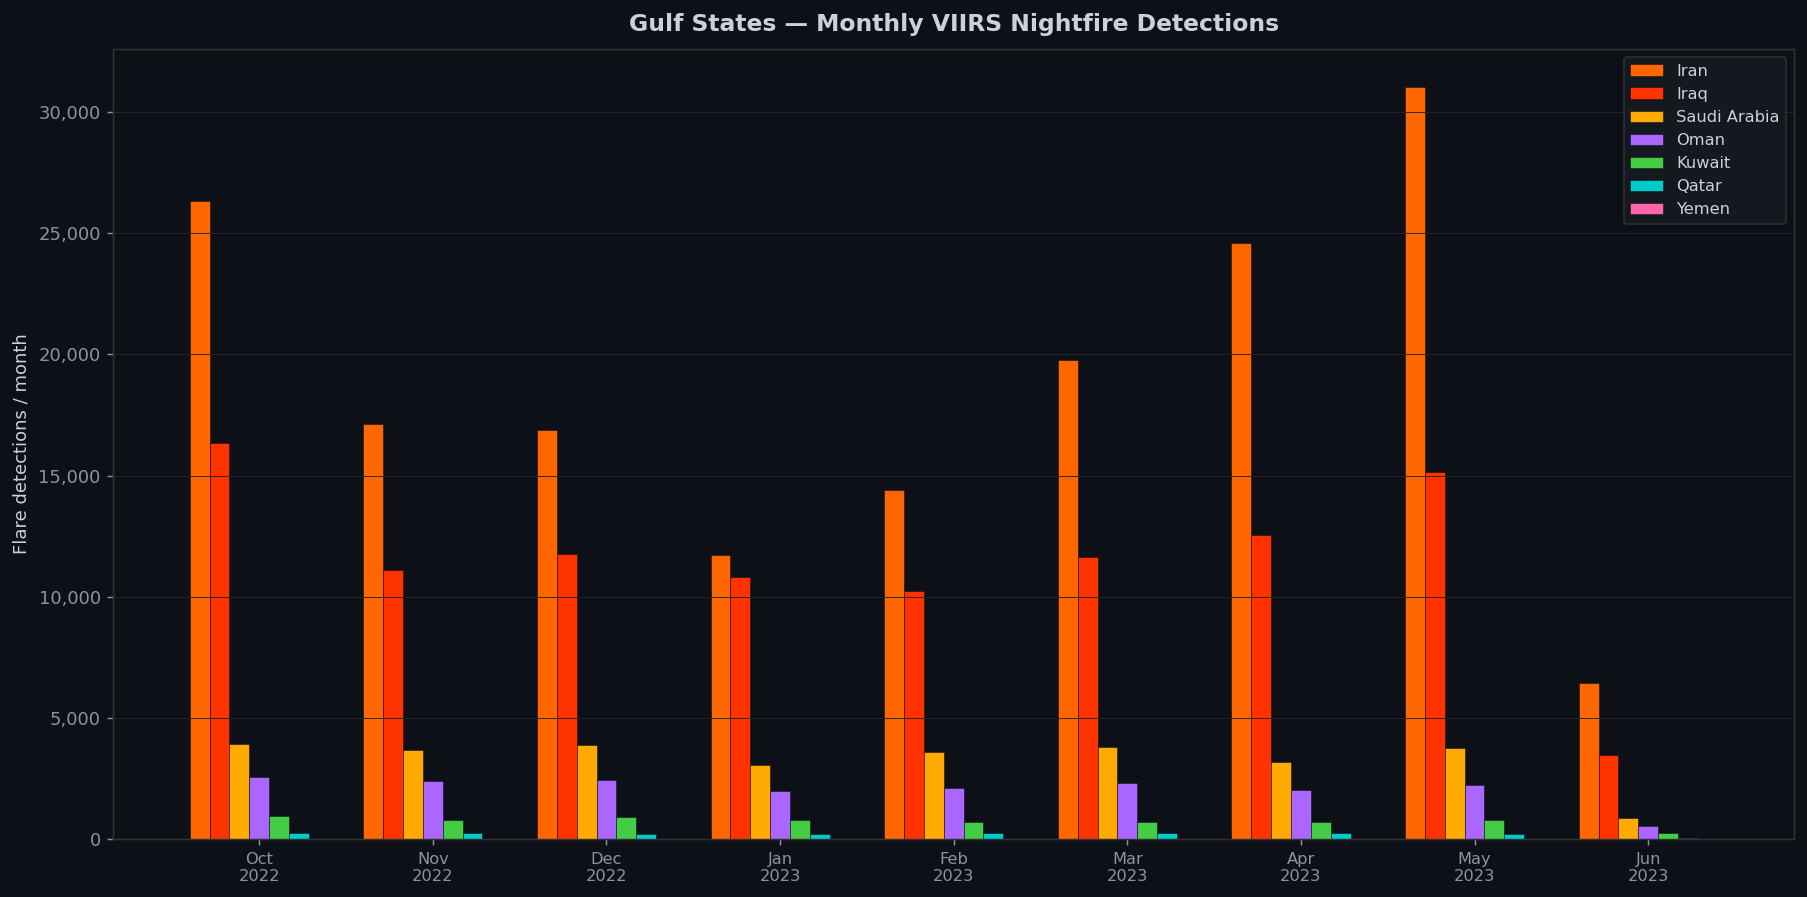

In [7]:
plot_timeseries_bars(
    ts_scaled,
    title="Gulf States — Monthly VIIRS Nightfire Detections",
    save_path=OUTPUT_DIR / "timeseries_bars.png",
)

## 6. Map — high temperature flares

High-temp detections 2023-06-01 to 2023-06-07: 6948


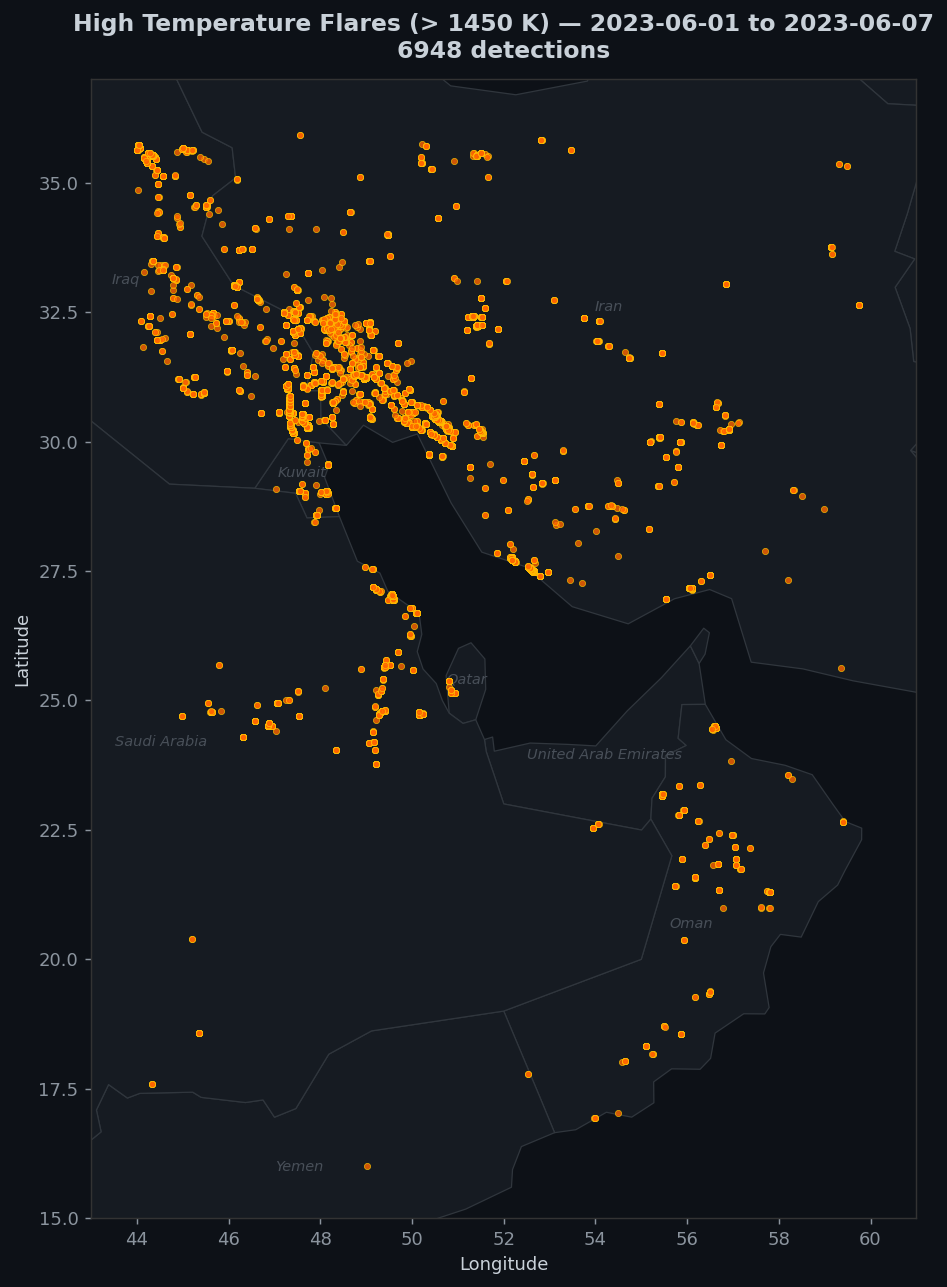

In [8]:
plot_hightemp_map(
    df,
    date_start=MAP_DATE_START,
    date_end=MAP_DATE_END,
    save_path=OUTPUT_DIR / "map_high_temp.png",
)

## 7. Export to CSV

In [9]:
export_csv(ts_scaled, OUTPUT_DIR / "monthly_timeseries.csv")

Exported: data\monthly_timeseries.csv
